# Tiny-circuit sweep

A minimal test problem: one brickwork circuit with **5 wires, depth 3**,
trained on a **single depth-3 output wire** using the solo-output methodology
from `solo_grokking.ipynb` (loss masked to that wire; eval still records all
5 outputs). Circuit seed 5 gives tap depths [3, 3, 1, 3, 2] with a real gate
in the last layer acting on wires 0, 1, 3; the target is **wire 0**, a
balanced function of all 5 inputs (verified below).

Sweeps 7 model shapes from the `sweep.py` scale grid at their tuned LRs
(`runs/lr_table.json`). With only 2^5 = 32 distinct inputs, a 256-batch
covers the whole input space ~8x per step, so train and eval distributions
coincide — expect fast saturation at every size. Use this as a pipeline
smoke test and a lower anchor for model-size scaling, not as a
generalization measurement.

In [2]:
import sys

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    import os
    %pip -q install -U "jax[cuda12]" optax
    if not os.path.exists("/content/circscale"):
        !git clone https://github.com/amdson/circscale.git /content/circscale
    %cd /content/circscale
    !git pull
    from google.colab import drive
    drive.mount("/content/drive")
    os.makedirs("/content/drive/MyDrive/circscale_runs", exist_ok=True)
    if not os.path.islink("runs"):
        os.symlink("/content/drive/MyDrive/circscale_runs", "runs")

/content/circscale
Already up to date.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## The circuit

Rebuilds exactly the circuit `train.py` will sample (same seeded RNG path)
and inspects the target output: tap depths, balance, relevant inputs,
Fourier degree, and the full 32-row truth table.

In [13]:
from itertools import product

import matplotlib.pyplot as plt
import numpy as np

from random_circuit import evaluate_np, sample_circuit
from train import RunConfig, load_run, run

# --- task: one tiny circuit, one output wire ---
N_WIRES, CIRC_DEPTH = 8, 4
CIRCUIT_SEED = 2
TARGET_WIRE = 0

circuit = sample_circuit(np.random.default_rng(CIRCUIT_SEED), N_WIRES, CIRC_DEPTH)
X = np.array(list(product([0, 1], repeat=N_WIRES)), dtype=np.uint8)  # all 32 inputs
Y = evaluate_np(circuit, X)
y = Y[:, TARGET_WIRE]

print("tap depths:", circuit.out_depths,
      f"-> target wire {TARGET_WIRE} at depth {circuit.out_depths[TARGET_WIRE]}")
print(f"balance: {y.mean():.3f}")

flip = np.eye(N_WIRES, dtype=np.uint8)
powers = 1 << np.arange(N_WIRES)[::-1]          # X rows are sorted by this key
rel = [i for i in range(N_WIRES) if np.any(y != y[(X ^ flip[i]) @ powers])]
print("relevant inputs:", rel)

subsets = X.astype(int)                          # reuse the 32 rows as subset masks
signs = 1 - 2 * X.astype(int)                    # inputs in +/-1
chi = np.prod(np.where(subsets[:, None, :] == 1, signs[None, :, :], 1), axis=2)
coeffs = chi @ (1 - 2 * y.astype(int)) / len(X)  # Fourier coefficients over all S
print("Fourier degree:", subsets[np.abs(coeffs) > 1e-9].sum(axis=1).max())
print("truth table:", "".join(map(str, y)))

tap depths: [4 2 1 2 2 4 2 1] -> target wire 0 at depth 4
balance: 0.500
relevant inputs: [0, 1, 2, 3, 4, 5, 6]
Fourier degree: 5
truth table: 0011000011001111111100000000111100110000001100001111000011110000001100001100111100000000111111110011000000110000000000000000000000110000110011111111000000001111110011111100111100001111000011110011000011001111000000001111111111001111110011111111111111111111


In [15]:
print(subsets.shape)

(256, 8)


## Sweep: 7 model sizes, tuned LRs

Shapes from the `sweep.py` scale grid; each LR is that shape's tuned value
from `runs/lr_table.json`.

In [16]:
# (width, mlp_depth, lr) — LRs from runs/lr_table.json (sweep.py lr-tune)
SHAPES = [
    (32,  2, 1e-2),
    (64,  3, 1e-2),
    (128, 4, 3e-3),
    (180, 5, 3e-3),
    (256, 6, 1e-3),
    (360, 7, 1e-3),
    (512, 8, 1e-3),
]
STEPS = 10_000
OUT_DIR = "runs/tiny5"
CHANCE = np.log(2)


def n_params(w, d, n_in=N_WIRES, n_out=N_WIRES, hr=4):
    h = hr * w
    return n_in * w + d * (w + w * h + h * w) + w + w * n_out


configs = [
    RunConfig(width=w, mlp_depth=d, lr=lr, steps=STEPS, train_frac=0.5,
              n_wires=N_WIRES, circ_depth=CIRC_DEPTH, circuit_seed=CIRCUIT_SEED,
              output_wires=(TARGET_WIRE,), eval_every=100, out_dir=OUT_DIR)
    for w, d, lr in SHAPES
]
print(f"{'shape':>8s} {'lr':>7s} {'params':>12s}")
for (w, d, lr), cfg in zip(SHAPES, configs):
    print(f"{f'w{w}d{d}':>8s} {lr:>7g} {n_params(w, d):>12,d}")
print(f"\n{len(configs)} runs x {STEPS:,} steps -> {OUT_DIR}/")

   shape      lr       params
   w32d2    0.01       16,992
   w64d3    0.01       99,584
  w128d4   0.003      526,976
  w180d5   0.003    1,299,960
  w256d6   0.001    3,151,616
  w360d7   0.001    7,266,240
  w512d8   0.001   16,790,016

7 runs x 10,000 steps -> runs/tiny5/


## Run (idempotent — interrupt and re-run freely)

In [ ]:
for cfg in configs:
    run(cfg)

w32_d2_b256_lr0.01_s10000_c8x4_tf0.5_ow0_cs2_ms0:   0%|          | 0/10000 [00:00<?, ?it/s]

[done] w32_d2_b256_lr0.01_s10000_c8x4_tf0.5_ow0_cs2_ms0: eval loss 0.7267, acc 0.9375, 0.3 min


w64_d3_b256_lr0.01_s10000_c8x4_tf0.5_ow0_cs2_ms0:   0%|          | 0/10000 [00:00<?, ?it/s]

[done] w64_d3_b256_lr0.01_s10000_c8x4_tf0.5_ow0_cs2_ms0: eval loss 0.7789, acc 0.9453, 0.3 min


w128_d4_b256_lr0.003_s10000_c8x4_tf0.5_ow0_cs2_ms0:   0%|          | 0/10000 [00:00<?, ?it/s]

[done] w128_d4_b256_lr0.003_s10000_c8x4_tf0.5_ow0_cs2_ms0: eval loss 0.6068, acc 0.9570, 0.4 min


w180_d5_b256_lr0.003_s10000_c8x4_tf0.5_ow0_cs2_ms0:   0%|          | 0/10000 [00:00<?, ?it/s]

## Target-wire trajectories

Left: eval BCE on the target wire vs samples D, one curve per model size
(chance dotted). Right: final loss vs parameter count.

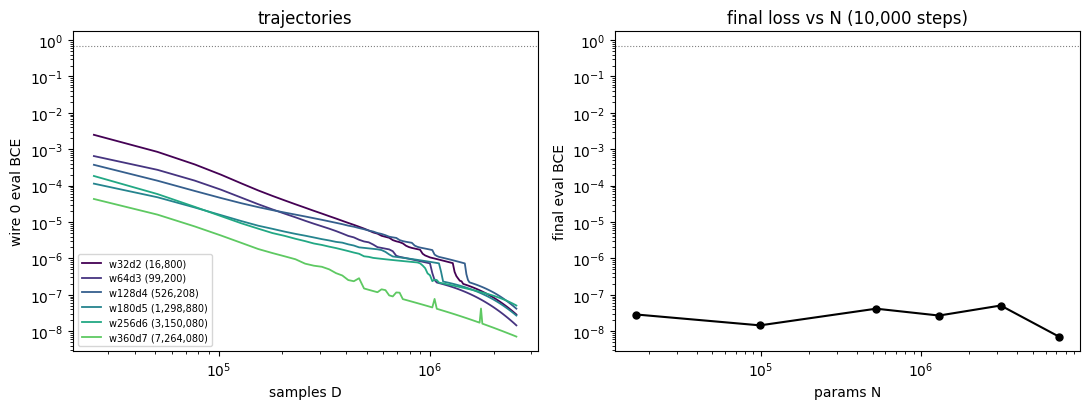

In [6]:
data = {}
for (w, d, lr), cfg in zip(SHAPES, configs):
    if cfg.npz_path.exists():
        data[(w, d)] = load_run(cfg.npz_path)[1]

cols = plt.cm.viridis(np.linspace(0, 0.9, len(SHAPES)))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
for (w, d, lr), col in zip(SHAPES, cols):
    if (w, d) not in data:
        continue
    r = data[(w, d)]
    m = r["eval_steps"] > 0
    D = r["eval_steps"][m] * configs[0].batch
    ax1.plot(D, r["per_out_loss"][m][:, TARGET_WIRE], color=col, lw=1.3,
             label=f"w{w}d{d} ({n_params(w, d):,})")
ax1.axhline(CHANCE, color="gray", ls=":", lw=0.8)
ax1.set(xscale="log", yscale="log", xlabel="samples D",
        ylabel=f"wire {TARGET_WIRE} eval BCE", title="trajectories")
ax1.legend(fontsize=7)

Ns = [n_params(w, d) for w, d, _ in SHAPES if (w, d) in data]
finals = [data[(w, d)]["per_out_loss"][-1, TARGET_WIRE]
          for w, d, _ in SHAPES if (w, d) in data]
ax2.plot(Ns, finals, "ko-", ms=5)
ax2.axhline(CHANCE, color="gray", ls=":", lw=0.8)
ax2.set(xscale="log", yscale="log", xlabel="params N",
        ylabel="final eval BCE", title=f"final loss vs N ({STEPS:,} steps)")
plt.tight_layout()

## Transition times

First D where the target's eval BCE crosses below 0.2 nats (NaN = never).

In [ ]:
def transition_D(steps, loss, batch, thresh=0.2):
    below = np.flatnonzero(loss < thresh)
    return steps[below[0]] * batch if len(below) else np.nan


print(f"{'shape':>8s} {'params':>12s} {'transition D':>13s} {'final acc':>10s}")
for w, d, lr in SHAPES:
    if (w, d) not in data:
        continue
    r = data[(w, d)]
    t = transition_D(r["eval_steps"], r["per_out_loss"][:, TARGET_WIRE],
                     configs[0].batch)
    print(f"{f'w{w}d{d}':>8s} {n_params(w, d):>12,d} {t:>13,.0f} "
          f"{r['per_out_acc'][-1, TARGET_WIRE]:>10.3f}")

## Low-data regime: half the inputs, unlimited compute

Fixes a random training pool of **16 of the 32 inputs** (`train_frac=0.5`,
`pool_seed=0` — the same pool for every shape) and resamples every batch
from that pool only. Eval enumerates all 32 inputs and records the
train-pool (`_tr`) and held-out (`_ho`) halves separately. 16 constraints
underdetermine the 32-bit truth table, so any above-chance held-out
performance is purely the network's inductive bias.

In [ ]:
ld_configs = [
    RunConfig(width=w, mlp_depth=d, lr=lr, steps=STEPS,
              n_wires=N_WIRES, circ_depth=CIRC_DEPTH, circuit_seed=CIRCUIT_SEED,
              output_wires=(TARGET_WIRE,), train_frac=0.5,
              eval_every=100, out_dir=OUT_DIR)
    for w, d, lr in SHAPES
]
for cfg in ld_configs:
    run(cfg)

## Train vs held-out trajectories

Per shape: wire-0 BCE on the 16 training inputs (dashed) vs the 16 held-out
inputs (solid) over training, log-log; chance dotted. Train loss can
underflow to exactly 0 once memorized — clipped at 1e-8 for the log axis.

In [ ]:
ld = {}
for (w, d, lr), cfg in zip(SHAPES, ld_configs):
    if cfg.npz_path.exists():
        ld[(w, d)] = load_run(cfg.npz_path)[1]

ncols = 4
nrows = -(-len(SHAPES) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows),
                         sharex=True, sharey=True)
for ax, (w, d, lr) in zip(axes.flat, SHAPES):
    if (w, d) not in ld:
        ax.axis("off")
        continue
    r = ld[(w, d)]
    m = r["eval_steps"] > 0
    steps = r["eval_steps"][m]
    tr = np.maximum(r["per_out_loss_tr"][m][:, TARGET_WIRE], 1e-8)
    ho = np.maximum(r["per_out_loss_ho"][m][:, TARGET_WIRE], 1e-8)
    ax.plot(steps, tr, "C0--", lw=1.2, label="train (16 inputs)")
    ax.plot(steps, ho, "C1-", lw=1.2, label="held-out (16 inputs)")
    ax.axhline(CHANCE, color="gray", ls=":", lw=0.8)
    ax.set(xscale="log", yscale="log", title=f"w{w}d{d} ({n_params(w, d):,})")
for ax in axes.flat[len(SHAPES):]:
    ax.axis("off")
axes.flat[0].legend(fontsize=7)
fig.supxlabel("step")
fig.supylabel(f"wire {TARGET_WIRE} BCE")
plt.tight_layout()

In [ ]:
print(f"{'shape':>8s} {'params':>12s} {'train BCE':>10s} "
      f"{'held-out BCE':>13s} {'held-out acc':>13s}")
for w, d, lr in SHAPES:
    if (w, d) not in ld:
        continue
    r = ld[(w, d)]
    print(f"{f'w{w}d{d}':>8s} {n_params(w, d):>12,d} "
          f"{r['per_out_loss_tr'][-1, TARGET_WIRE]:>10.4f} "
          f"{r['per_out_loss_ho'][-1, TARGET_WIRE]:>13.4f} "
          f"{r['per_out_acc_ho'][-1, TARGET_WIRE]:>13.3f}")

## Notes

- 32 distinct inputs at batch 256 means every step sees the whole input
  space ~8x: in the online section train and eval coincide, so read those
  curves as optimization / feature-learning speed, not sample efficiency.
- Non-target head columns get no gradient (solo masking), so `per_out_loss`
  on wires 1–4 reflects init noise — don't read incidental learning off them.
- The `[done]` line reports the trained wire(s) only; low-data runs also
  print the all-input eval, which mixes the train and held-out halves —
  use `per_out_loss_ho` / `per_out_acc_ho` for generalization.
- Held-out accuracy has granularity 1/16 = 0.0625 (16 held-out inputs).
- One model seed per shape (`ms0`), matching `sweep.py`; pass extra
  `model_seed=` configs if a shape looks anomalous. The pool is also worth
  varying (`pool_seed=`) — which 16 inputs are seen changes the task.